# Metabolite Catalog Exploration

**File**: `human_database_merge_unique_metab_with_HMDB_Info.csv`  
**Goal**: Characterize the consolidated, non-redundant metabolite list and assess its coverage, chemical diversity, and database provenance — laying the groundwork for downstream cancer cell-cell communication analysis.

---

## 1. Environment Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

## 2. Load Data

In [8]:
data_path = '../output/human_database_merge_unique_metab_with_HMDB_Info.csv'
df = pd.read_csv(data_path)
print(f'Dataset loaded: {len(df):,} unique metabolites, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset loaded: 401 unique metabolites, 10 columns
Columns: ['Metabolite_Name', 'database', 'databases_count', 'HMDB_ID', 'HMDB_Name', 'SMILES', 'INCHIKEY', 'CHEMICAL_FORMULA', 'AVERAGE_MASS', 'MONO_MASS']


,Metabolite_Name,database,databases_count,HMDB_ID,HMDB_Name,SMILES,INCHIKEY,CHEMICAL_FORMULA,AVERAGE_MASS,MONO_MASS
0,(r)-5-diphosphomevalonic acid,"CELLINKER2, MEBOCOST, MRCLINKDB",3,HMDB0001090,(R)-5-Diphosphomevalonic acid,C[C@@](O)(CCOP(O)(=O)OP(O)(O)=O)CC(O)=O,SIGQQUBJQXSAMW-ZCFIWIBFSA-N,C6H14O10P2,308.1169,308.006220
1,(r)-lipoic acid,METALIGAND,1,HMDB0001451,(R)-Lipoic acid,OC(=O)CCCC[C@@H]1CCSS1,AGBQKNBQESQNJD-SSDOTTSWSA-N,C8H14O2S2,206.3260,206.043521
2,"1,25-dihydroxyvitamin d3-26,23-lactone","CELLINKER2, MRCLINKDB",2,HMDB0000969,"1,25-Dihydroxyvitamin D3-26,23-lactone",[H][C@@]1(CC[C@@]2([H])\C(CCC[C@]12C)=C\C=C1\C...,WMYIVSWWSRCZFA-RWVJFQLJSA-N,C27H40O5,444.6035,444.287574
3,1-methylhistamine,METALIGAND,1,HMDB0000898,1-Methylhistamine,CN1C=NC(CCN)=C1,FHQDWPCFSJMNCT-UHFFFAOYSA-N,C6H11N3,125.1716,125.095297
4,11-cis-retinol,"CELLINKER2, MEBOCOST, MRCLINKDB",3,HMDB0006216,11-cis-Retinol,C\C(=C/CO)\C=C/C=C(\C)/C=C/C1=C(C)CCCC1(C)C,FPIPGXGPPPQFEQ-IOUUIBBYSA-N,C20H30O,286.4516,286.229666


## 3. Data Completeness Overview

How complete is each field across the 401 metabolites?

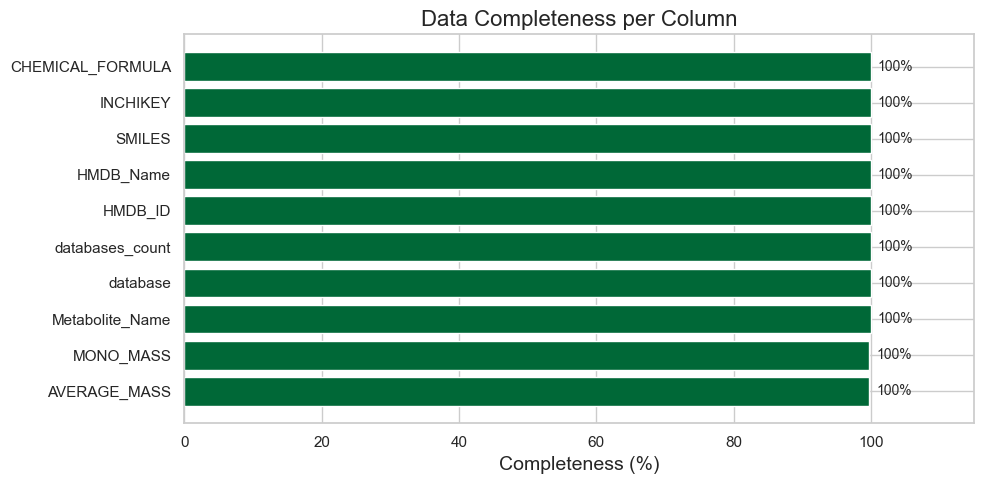

In [9]:
completeness = (df.notna().sum() / len(df) * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(completeness.index, completeness.values, color=plt.cm.RdYlGn(completeness.values / 100))
ax.set_xlabel('Completeness (%)')
ax.set_title('Data Completeness per Column')
for bar, val in zip(bars, completeness.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=10)
ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

---

## 4. Database Provenance

### 4.1. Cross-Database Validation
Metabolites supported by more databases have higher confidence.

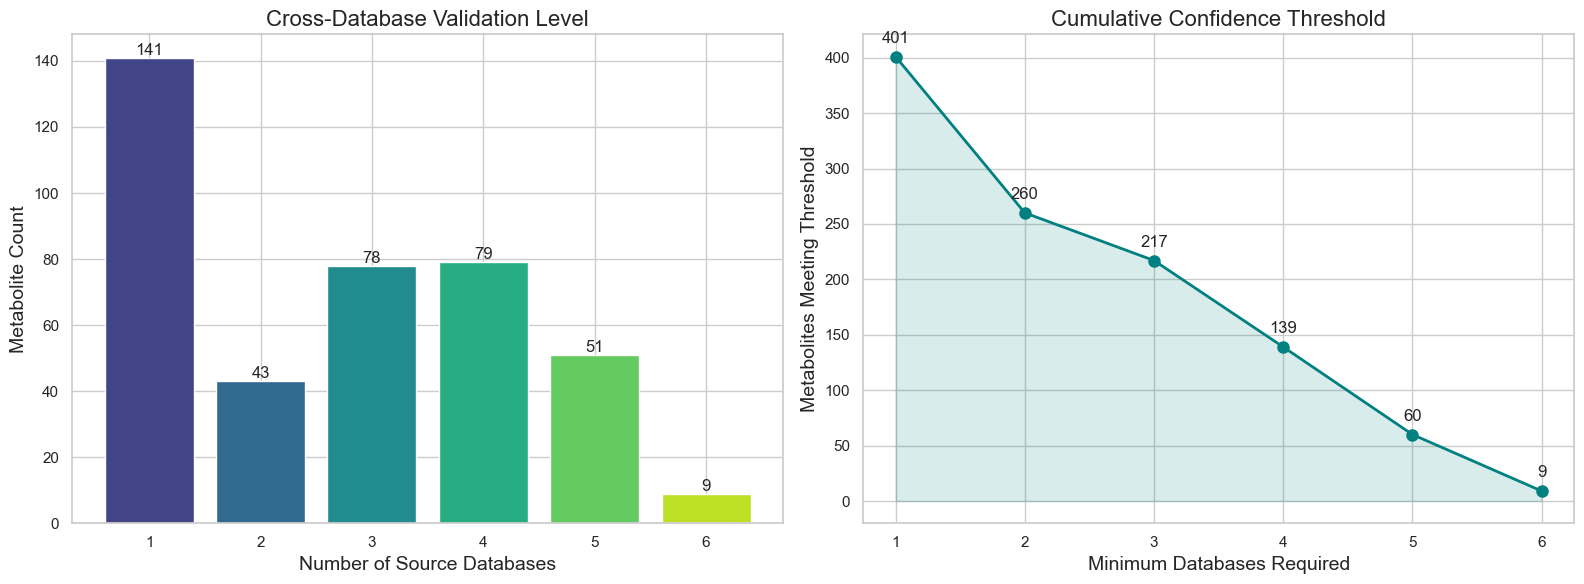


→ 217 metabolites (54.1%) are supported by 3+ databases (high confidence).
→ 141 metabolites (35.2%) are unique to a single database.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Count distribution
ax = axes[0]
vc = df['databases_count'].value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(vc)))
bars = ax.bar(vc.index, vc.values, color=colors, edgecolor='white')
for b in bars:
    ax.annotate(f'{int(b.get_height())}', (b.get_x() + b.get_width()/2., b.get_height()),
                ha='center', va='bottom', fontsize=12)
ax.set_xlabel('Number of Source Databases')
ax.set_ylabel('Metabolite Count')
ax.set_title('Cross-Database Validation Level')

# Right: Cumulative confidence
ax2 = axes[1]
cumul = vc.iloc[::-1].cumsum().iloc[::-1]
ax2.plot(cumul.index, cumul.values, 'o-', color='teal', markersize=8, linewidth=2)
ax2.fill_between(cumul.index, cumul.values, alpha=0.15, color='teal')
ax2.set_xlabel('Minimum Databases Required')
ax2.set_ylabel('Metabolites Meeting Threshold')
ax2.set_title('Cumulative Confidence Threshold')
for x, y in zip(cumul.index, cumul.values):
    ax2.annotate(f'{y}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()

print(f'\n→ {(df["databases_count"] >= 3).sum()} metabolites ({(df["databases_count"] >= 3).mean()*100:.1f}%) are supported by 3+ databases (high confidence).')
print(f'→ {(df["databases_count"] == 1).sum()} metabolites ({(df["databases_count"] == 1).mean()*100:.1f}%) are unique to a single database.')

### 4.2. Individual Database Contributions

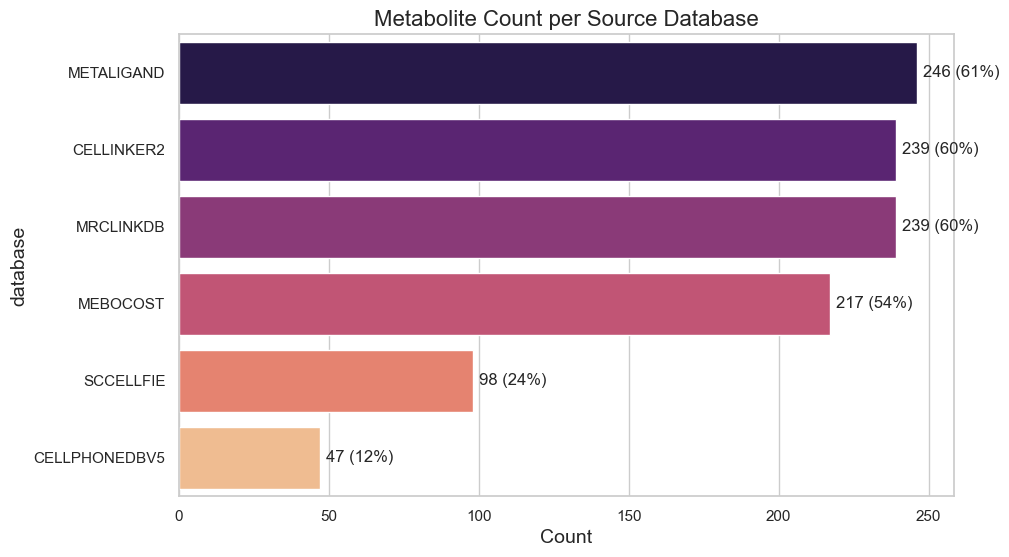

In [11]:
db_series = df['database'].str.split(', ').explode()
db_counts = db_series.value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=db_counts.values, y=db_counts.index, hue=db_counts.index, palette='magma', legend=False)
plt.title('Metabolite Count per Source Database')
plt.xlabel('Count')
for i, v in enumerate(db_counts.values):
    plt.text(v + 2, i, f'{v} ({v/len(df)*100:.0f}%)', va='center')
plt.show()

#### Note on Cellinker2 and MRCLinkDB Overlap
In the merged dataset, **Cellinker2** and **MRCLinkDB** often show 100% overlap and zero exclusive metabolites in the counts below. This is an expected result of the pipeline logic in `merge_dbs_claude.py`, which identifies metabolites shared between these two sources and combines them into single entries (marked as `MRCLinkDB/Cellinker2`). Consequently, while they both contribute significant data, they appear as a joint set in the unique metabolite mapping.

### 4.3. Pairwise Database Overlap (Co-occurrence Matrix)
Which databases share the most metabolites?

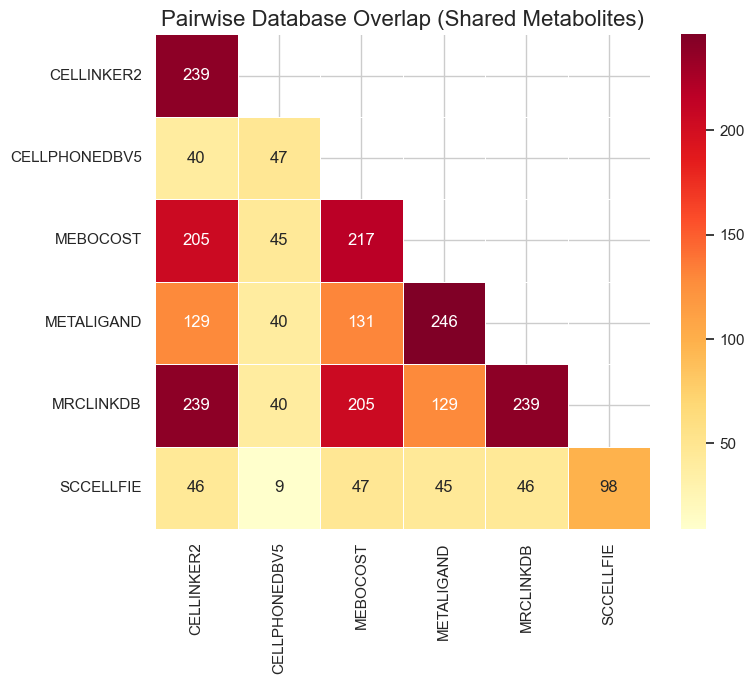


=== Database-Exclusive Metabolites ===
  CELLINKER2: 0 exclusive metabolites
  CELLPHONEDBV5: 1 exclusive metabolites
  MEBOCOST: 2 exclusive metabolites
  METALIGAND: 99 exclusive metabolites
  MRCLINKDB: 0 exclusive metabolites
  SCCELLFIE: 39 exclusive metabolites


In [12]:
# Build binary presence matrix
db_list = df['database'].str.split(', ')
all_dbs = sorted(db_series.unique())
presence = pd.DataFrame({db: db_list.apply(lambda x: db in x) for db in all_dbs})

# Overlap matrix (cast to int to ensure correct integer counts)
overlap = presence.astype(int).T.dot(presence.astype(int))

# Plot
mask = np.triu(np.ones_like(overlap, dtype=bool), k=1)
plt.figure(figsize=(8, 7))
sns.heatmap(overlap, annot=True, fmt='d', cmap='YlOrRd', mask=mask, linewidths=0.5,
            xticklabels=all_dbs, yticklabels=all_dbs)
plt.title('Pairwise Database Overlap (Shared Metabolites)')
plt.tight_layout()
plt.show()

# Unique metabolites per database
print('\n=== Database-Exclusive Metabolites ===')
for db in all_dbs:
    exclusive = presence[presence[db] & (presence.sum(axis=1) == 1)]
    print(f'  {db}: {len(exclusive)} exclusive metabolites')

---

## 5. HMDB Annotation Coverage

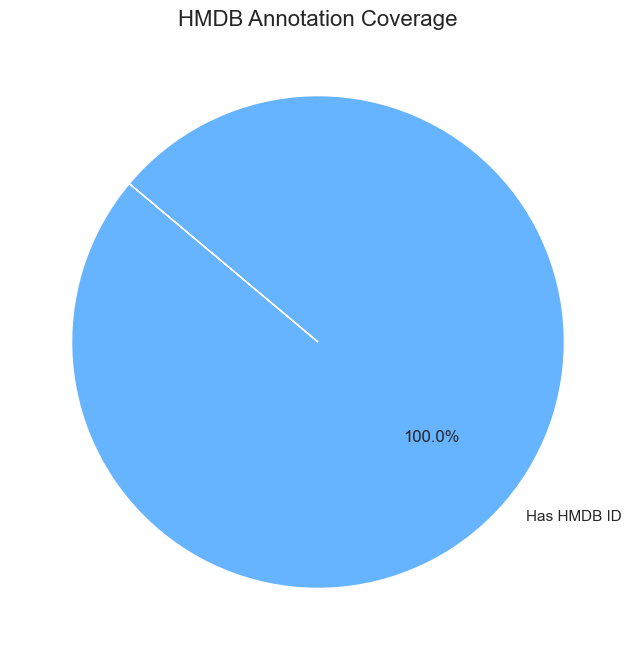

401/401 metabolites have HMDB identifiers.


In [13]:
hmdb_counts = df['HMDB_ID'].notna().value_counts()
labels = [('Has HMDB ID' if i else 'Missing HMDB ID') for i in hmdb_counts.index]
explode = [0.05] * len(hmdb_counts) if len(hmdb_counts) > 1 else [0]

plt.figure(figsize=(8, 8))
plt.pie(hmdb_counts, labels=labels, autopct='%1.1f%%', 
        startangle=140, colors=['#66b3ff','#ff9999'], explode=explode)
plt.title('HMDB Annotation Coverage')
plt.show()

print(f'{hmdb_counts.get(True, 0)}/{len(df)} metabolites have HMDB identifiers.')

---

## 6. Chemical Space Characterization

### 6.1. Molecular Weight Distribution
Small molecules (<500 Da) are typical metabolite signaling ligands.

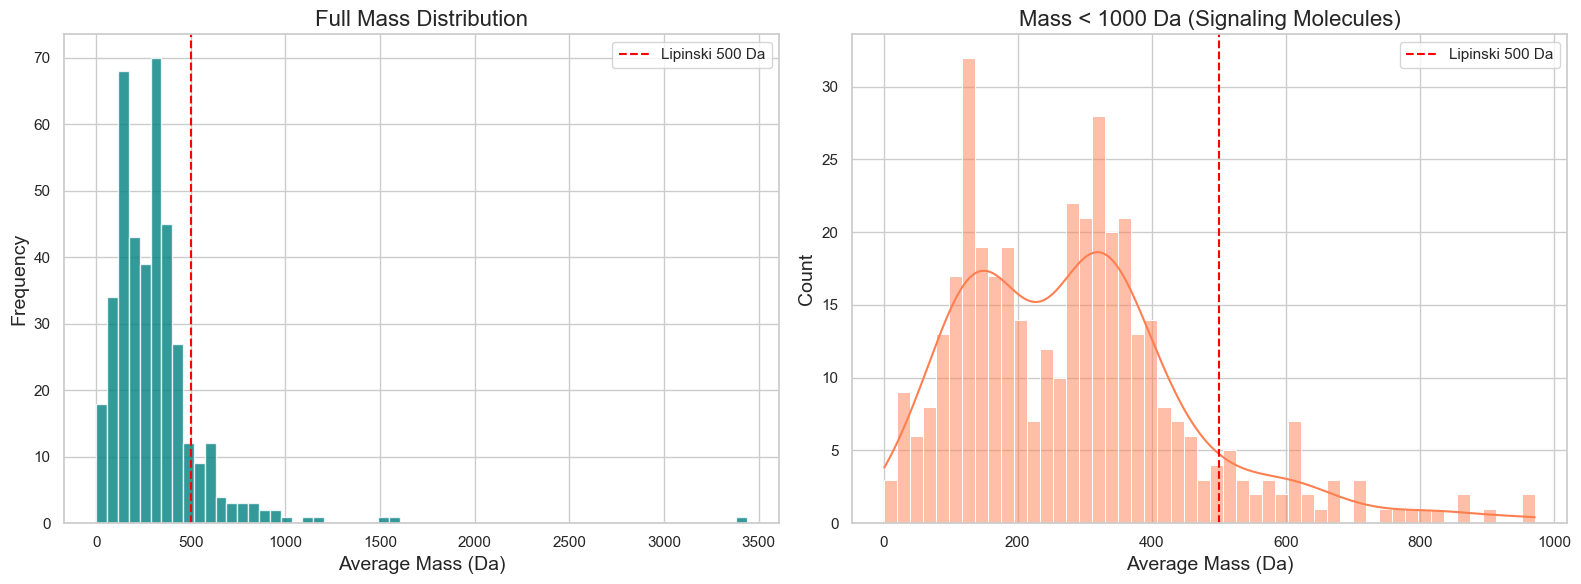


→ 352/400 (88.0%) metabolites are < 500 Da (typical small-molecule ligands).
→ Median mass: 286.4 Da
→ Range: 1.0 – 3438.0 Da


In [14]:
masses = df['AVERAGE_MASS'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full range histogram
ax = axes[0]
ax.hist(masses, bins=60, color='teal', edgecolor='white', alpha=0.8)
ax.axvline(500, color='red', linestyle='--', label='Lipinski 500 Da')
ax.set_xlabel('Average Mass (Da)')
ax.set_ylabel('Frequency')
ax.set_title('Full Mass Distribution')
ax.legend()

# Focused range with KDE
ax2 = axes[1]
sns.histplot(masses[masses < 1000], bins=50, kde=True, color='coral', ax=ax2)
ax2.axvline(500, color='red', linestyle='--', label='Lipinski 500 Da')
ax2.set_xlabel('Average Mass (Da)')
ax2.set_title('Mass < 1000 Da (Signaling Molecules)')
ax2.legend()

plt.tight_layout()
plt.show()

below500 = (masses < 500).sum()
print(f'\n→ {below500}/{len(masses)} ({below500/len(masses)*100:.1f}%) metabolites are < 500 Da (typical small-molecule ligands).')
print(f'→ Median mass: {masses.median():.1f} Da')
print(f'→ Range: {masses.min():.1f} – {masses.max():.1f} Da')

### 6.2. Elemental Composition Analysis
Parsing chemical formulas to understand the elemental diversity.

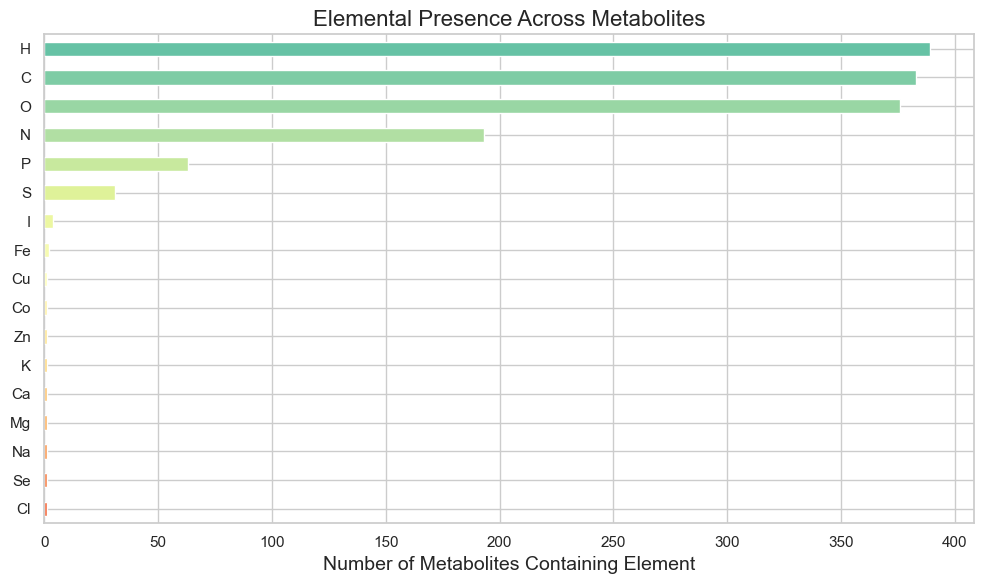


=== Heteroatom/Metal-Containing Metabolites ===
  S: 31 metabolites (7.7%)
  N: 193 metabolites (48.1%)
  P: 63 metabolites (15.7%)
  Cl: 1 metabolites (0.2%)
  I: 4 metabolites (1.0%)
  Se: 1 metabolites (0.2%)
  Fe: 2 metabolites (0.5%)
  Zn: 1 metabolites (0.2%)
  Cu: 1 metabolites (0.2%)
  Co: 1 metabolites (0.2%)


In [15]:
def parse_formula(formula):
    """Extract element counts from a chemical formula string."""
    if pd.isna(formula):
        return {}
    elements = re.findall(r'([A-Z][a-z]?)(\d*)', str(formula))
    return {el: int(count) if count else 1 for el, count in elements if el}

parsed = df['CHEMICAL_FORMULA'].apply(parse_formula)
all_elements = set()
for d in parsed:
    all_elements.update(d.keys())

# Count presence of each element
element_presence = {el: sum(1 for d in parsed if el in d) for el in all_elements}
element_series = pd.Series(element_presence).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
element_series.plot.barh(color=plt.cm.Spectral(np.linspace(0.2, 0.8, len(element_series))))
plt.xlabel('Number of Metabolites Containing Element')
plt.title('Elemental Presence Across Metabolites')
plt.tight_layout()
plt.show()

# Heteroatom analysis
heteroatoms = ['S', 'N', 'P', 'Cl', 'Br', 'I', 'Se', 'Fe', 'Zn', 'Cu', 'Co', 'Mn']
print('\n=== Heteroatom/Metal-Containing Metabolites ===')
for el in heteroatoms:
    count = element_presence.get(el, 0)
    if count > 0:
        print(f'  {el}: {count} metabolites ({count/len(df)*100:.1f}%)')

### 6.3. Molecular Weight Classes
Categorizing metabolites by mass bins relevant to signaling biology.

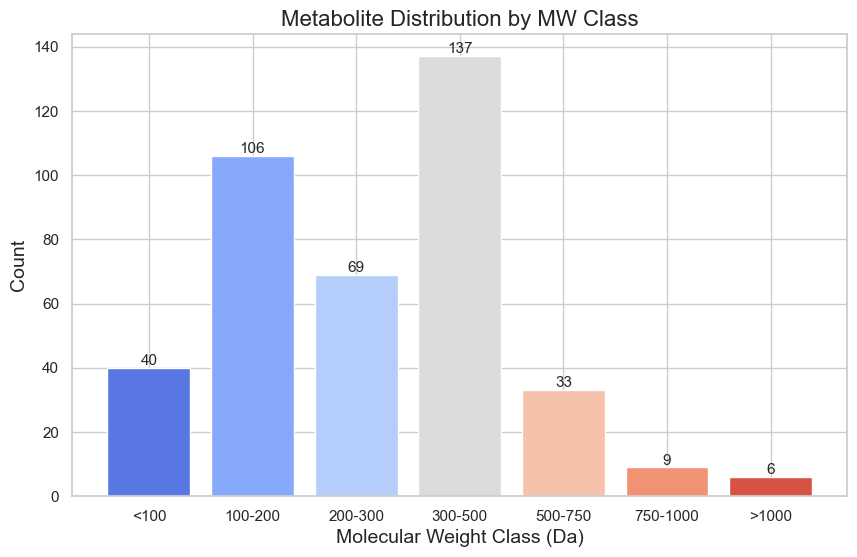


=== Database Breakdown by MW Class ===
  <100 Da (40 metabs): {'CELLINKER2': 28, 'MRCLINKDB': 28, 'MEBOCOST': 25, 'METALIGAND': 24, 'SCCELLFIE': 5, 'CELLPHONEDBV5': 1}
  100-200 Da (106 metabs): {'METALIGAND': 77, 'MEBOCOST': 63, 'CELLINKER2': 63, 'MRCLINKDB': 63, 'SCCELLFIE': 33, 'CELLPHONEDBV5': 10}
  200-300 Da (69 metabs): {'CELLINKER2': 45, 'MRCLINKDB': 45, 'MEBOCOST': 42, 'METALIGAND': 38, 'SCCELLFIE': 19, 'CELLPHONEDBV5': 8}
  300-500 Da (137 metabs): {'METALIGAND': 89, 'CELLINKER2': 85, 'MRCLINKDB': 85, 'MEBOCOST': 73, 'CELLPHONEDBV5': 24, 'SCCELLFIE': 15}
  500-750 Da (33 metabs): {'SCCELLFIE': 17, 'METALIGAND': 14, 'CELLINKER2': 14, 'MRCLINKDB': 14, 'MEBOCOST': 12, 'CELLPHONEDBV5': 2}
  750-1000 Da (9 metabs): {'SCCELLFIE': 7, 'METALIGAND': 2, 'CELLINKER2': 2, 'MRCLINKDB': 2, 'CELLPHONEDBV5': 1, 'MEBOCOST': 1}
  >1000 Da (6 metabs): {'CELLINKER2': 2, 'MRCLINKDB': 2, 'SCCELLFIE': 2, 'MEBOCOST': 1, 'CELLPHONEDBV5': 1, 'METALIGAND': 1}


In [16]:
bins = [0, 100, 200, 300, 500, 750, 1000, float('inf')]
labels_mw = ['<100', '100-200', '200-300', '300-500', '500-750', '750-1000', '>1000']
df['MW_Class'] = pd.cut(df['AVERAGE_MASS'], bins=bins, labels=labels_mw, right=False)

mw_counts = df['MW_Class'].value_counts().reindex(labels_mw)
colors_mw = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(labels_mw)))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(mw_counts.index, mw_counts.values, color=colors_mw, edgecolor='white')
ax.set_xlabel('Molecular Weight Class (Da)')
ax.set_ylabel('Count')
ax.set_title('Metabolite Distribution by MW Class')
for b in bars:
    if b.get_height() > 0:
        ax.annotate(f'{int(b.get_height())}', (b.get_x() + b.get_width()/2., b.get_height()),
                    ha='center', va='bottom', fontsize=11)
plt.show()

# Cross-reference: which databases contribute large molecules?
print('\n=== Database Breakdown by MW Class ===')
for mw_label in labels_mw:
    subset = df[df['MW_Class'] == mw_label]
    if len(subset) > 0:
        dbs = subset['database'].str.split(', ').explode().value_counts()
        print(f'  {mw_label} Da ({len(subset)} metabs): {dbs.to_dict()}')

# Cleanup
df.drop(columns=['MW_Class'], inplace=True)

---

## 7. Confidence Tiers for Downstream Analysis

Assigning a confidence tier based on cross-database validation and annotation completeness. This provides a prioritization framework for selecting metabolites for cancer CCC analysis.

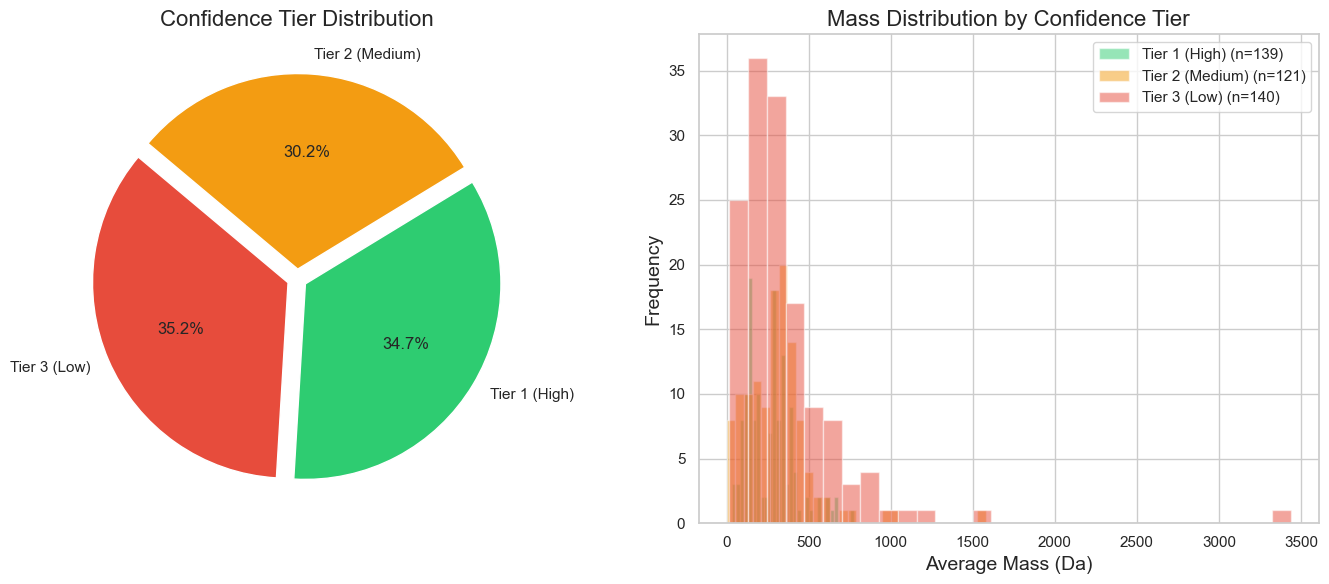


=== Confidence Tier Summary ===
  Tier 3 (Low): 141 metabolites (35.2%)
  Tier 1 (High): 139 metabolites (34.7%)
  Tier 2 (Medium): 121 metabolites (30.2%)

→ Tier 1 metabolites are recommended as the primary set for TCGA/scRNAseq integration.


In [17]:
def assign_tier(row):
    score = row['databases_count']
    has_smiles = pd.notna(row['SMILES'])
    has_mass = pd.notna(row['AVERAGE_MASS'])
    if score >= 4 and has_smiles and has_mass:
        return 'Tier 1 (High)'
    elif score >= 2 and has_smiles:
        return 'Tier 2 (Medium)'
    else:
        return 'Tier 3 (Low)'

df['Confidence_Tier'] = df.apply(assign_tier, axis=1)
tier_counts = df['Confidence_Tier'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
tier_colors = {'Tier 1 (High)': '#2ecc71', 'Tier 2 (Medium)': '#f39c12', 'Tier 3 (Low)': '#e74c3c'}
axes[0].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
            colors=[tier_colors[t] for t in tier_counts.index], startangle=140, explode=[0.05]*len(tier_counts))
axes[0].set_title('Confidence Tier Distribution')

# Mass distribution by tier
for tier in ['Tier 1 (High)', 'Tier 2 (Medium)', 'Tier 3 (Low)']:
    subset = df[df['Confidence_Tier'] == tier]['AVERAGE_MASS'].dropna()
    if len(subset) > 0:
        axes[1].hist(subset, bins=30, alpha=0.5, label=f'{tier} (n={len(subset)})', color=tier_colors[tier])
axes[1].set_xlabel('Average Mass (Da)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Mass Distribution by Confidence Tier')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\n=== Confidence Tier Summary ===')
for tier in tier_counts.index:
    n = tier_counts[tier]
    print(f'  {tier}: {n} metabolites ({n/len(df)*100:.1f}%)')

print(f'\n→ Tier 1 metabolites are recommended as the primary set for TCGA/scRNAseq integration.')

# Cleanup
df.drop(columns=['Confidence_Tier'], inplace=True)

---

## 8. Summary Table: Key Metabolite Catalog Statistics

In [18]:
summary = {
    'Total unique metabolites': len(df),
    'With HMDB ID': df['HMDB_ID'].notna().sum(),
    'With SMILES': df['SMILES'].notna().sum(),
    'With chemical formula': df['CHEMICAL_FORMULA'].notna().sum(),
    'Median mass (Da)': f"{df['AVERAGE_MASS'].median():.1f}",
    'In 1 database only': (df['databases_count'] == 1).sum(),
    'In 2+ databases': (df['databases_count'] >= 2).sum(),
    'In 3+ databases (high confidence)': (df['databases_count'] >= 3).sum(),
    'In all 6 databases': (df['databases_count'] == 6).sum(),
}
pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])

,Value
Total unique metabolites,401
With HMDB ID,401
With SMILES,401
With chemical formula,401
Median mass (Da),286.4
In 1 database only,141
In 2+ databases,260
In 3+ databases (high confidence),217
In all 6 databases,9
